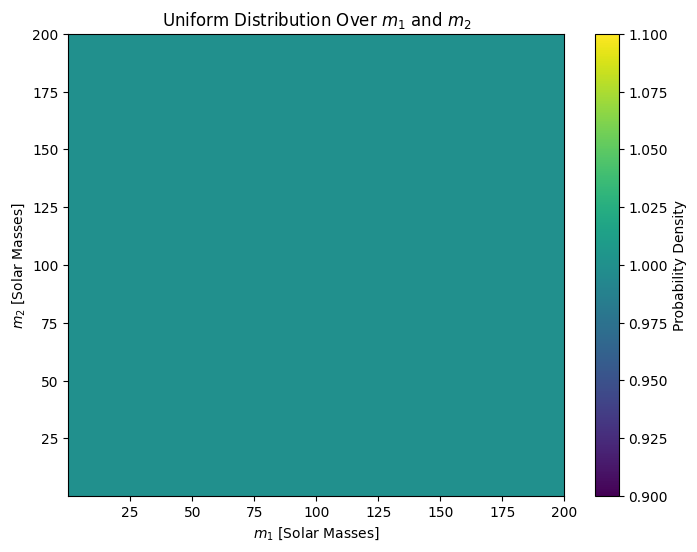

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for m1 and m2
m1_min, m1_max = 0.1, 200  # Solar masses
m2_min, m2_max = 0.1, 200  # Solar masses

# Generate a grid of m1 and m2 values
m1 = np.linspace(m1_min, m1_max, 3000)
m2 = np.linspace(m2_min, m2_max, 3000)
M1, M2 = np.meshgrid(m1, m2)

# Plotting
plt.figure(figsize=(8, 6))
plt.pcolormesh(M1, M2, np.ones_like(M1), shading='auto', cmap='viridis')

plt.colorbar(label='Probability Density')
plt.xlabel(r'$m_1$ [Solar Masses]')
plt.ylabel(r'$m_2$ [Solar Masses]')
plt.title('Uniform Distribution Over $m_1$ and $m_2$')
plt.xlim(m1_min, m1_max)
plt.ylim(m2_min, m2_max)

plt.show()


### Reconstructed PDF

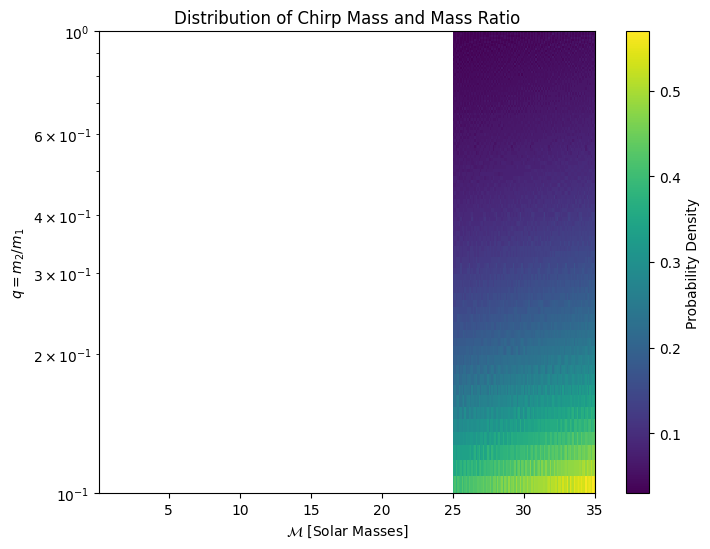

In [37]:
# Define the function to compute chirp mass and mass ratio
def chirp_mass_and_mass_ratio(m1, m2):
    q = m2 / m1  # mass ratio
    M = (m1 * m2)**(3/5) / (m1 + m2)**(1/5)  # chirp mass
    return M, q

# Compute chirp mass and mass ratio for each pair (m1, m2)
M_chirp, q = chirp_mass_and_mass_ratio(M1, M2)

# Filter out invalid values where q is not a number or infinite
#valid_mask = np.isfinite(M_chirp) & np.isfinite(q) & (q <= 4) & (M_chirp <= 35) & (M_chirp >= 25)
#valid_mask = np.isfinite(M_chirp) & np.isfinite(q) & (q <= 4.01) & (q >= 1) & (M_chirp <= 10) #& (M_chirp >= 25)
valid_mask = np.isfinite(M_chirp) & np.isfinite(q) & (q <= 1)& (q >= 0.1)& (M_chirp <= 35) #& (M_chirp >= 25)

# Filter the chirp mass and mass ratio arrays
M_chirp_filtered = M_chirp[valid_mask]
q_filtered = q[valid_mask]

# Plotting
plt.figure(figsize=(8, 6))

# Use a logarithmic scale for q since it ranges widely
#plt.hexbin(M_chirp_filtered, np.log10(q_filtered), gridsize=100, cmap='viridis')
plt.hist2d(M_chirp_filtered, q_filtered, bins=100,density=True, cmap='viridis')
plt.ylim()
plt.colorbar(label='Probability Density')
plt.xlabel(r's$\mathcal{M}$ [Solar Masses]')
#plt.ylabel(r'$\log_{10}(m_1/m_2)$')
plt.yscale('log')
plt.ylim(0.1,1)
plt.xlim(0.1,35)
plt.ylabel(r'$q = m_2/m_1$')
plt.title('Distribution of Chirp Mass and Mass Ratio')
plt.savefig('figures/pdf_Mq.png')
plt.show()


## Analitical PDF

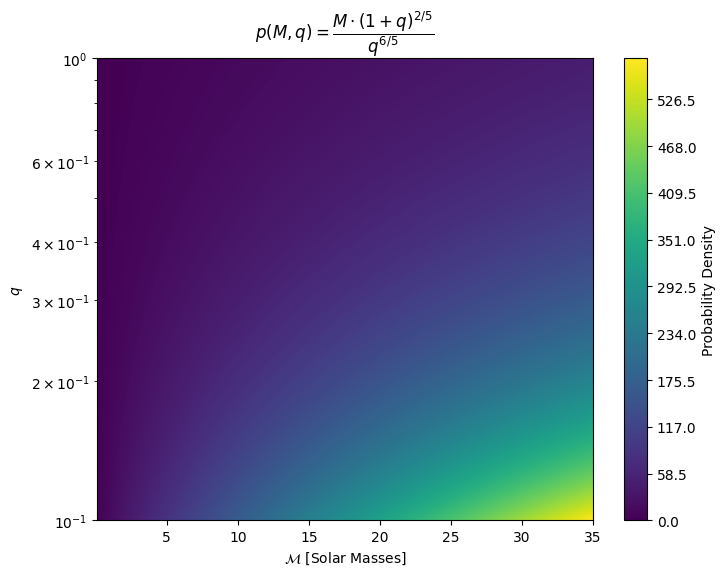

In [36]:
# Define the probability distribution function
def p_M_q(M, q):
    return (M * (1 + q)**(2/5)) / q**(6/5)

# Create a grid of M and q values
M = np.linspace(0.1, 35, 1000)  # Avoid M = 0 to prevent trivial zero
q = np.linspace(0.1, 1, 1000)  # Avoid q = 0 to prevent division by zero
M, q = np.meshgrid(M, q)

# Calculate the PDF values over the grid
pdf = p_M_q(M, q)
# Plot the PDF using a contour plot
plt.figure(figsize=(8, 6))
contour = plt.contourf(M, q, pdf, levels=500, cmap='viridis')
plt.colorbar(contour, label='Probability Density')
plt.xlabel('M')
plt.ylabel(r'$q$')
plt.xlabel(r'$\mathcal{M}$ [Solar Masses]')
plt.yscale('log')
plt.ylim(0.1,1)
plt.title(r'$p(M,q) = \dfrac{M \cdot (1+q)^{2/5}}{q^{6/5}}$')
plt.savefig('figures/pdf_analitical.png')
plt.show()
